# Fourier Transform

## Fourier Transform Definition

$$G(f) = \int_{-\infty}^\infty g(t) e^{-i 2 \pi f t} dt$$


## Discrete Fourier Transform (DFT) Definition
$$G(\frac{n}{N}) = \sum_{k=0}^{N-1} g(k) e^{-i 2 \pi k \frac{n}{N} }$$

where

* $N$ is the total number of samples
* $g(k)$ is the kth sample for the time-domain function (i.e. the DFT input)
* $G(\frac{n}{N})$ is the output of the DFT for the frequency that is $\frac{n}{N}$ cycles per sample; so to get the frequency, you have to multiply $n/N$ by the sample rate.

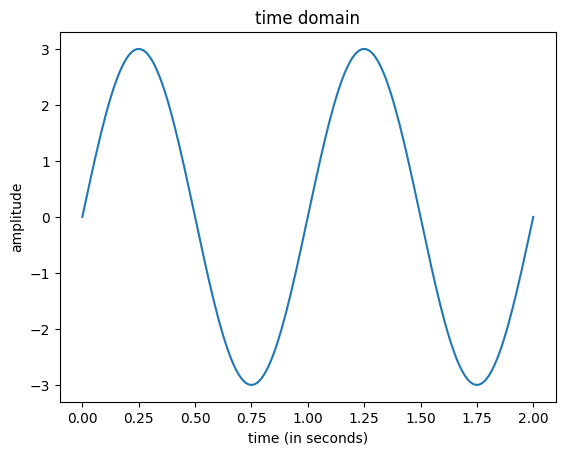

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy

# Graphing helper function
def setup_graph(title='', x_label='', y_label='', fig_size=None):
    fig = plt.figure()
    if fig_size != None:
        fig.set_size_inches(fig_size[0], fig_size[1])
    ax = fig.add_subplot(111)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)


freq = 1 #hz - cycles per second
amplitude = 3
time_to_plot = 2 # second
sample_rate = 100 # samples per second
num_samples = sample_rate * time_to_plot

t = np.linspace(0, time_to_plot, num_samples)
signal = [amplitude * np.sin(freq * i * 2*np.pi) for i in t] # Explain the 2*pi

setup_graph(x_label='time (in seconds)', y_label='amplitude', title='time domain')
plt.plot(t, signal)

# Convert to the Frequency Domain
# Use the FFT to convert the real-valued time signal into its
# frequency-domain representation (magnitude vs Hz).



In [2]:
fft_output = np.fft.rfft(signal)
magnitude_only = [np.sqrt(i.real**2 + i.imag**2)/len(fft_output) for i in fft_output]
frequencies = [(i*1.0/num_samples)*sample_rate for i in range(num_samples//2+1)]

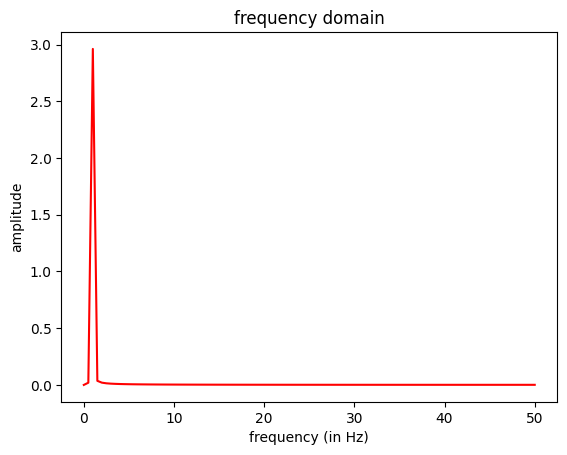

In [3]:
setup_graph(x_label='frequency (in Hz)', y_label='amplitude', title='frequency domain')
plt.plot(frequencies, magnitude_only, 'r')

---

## Motivation

We start with introduction to the Fourier method. The basic idea of this method is to express some complicated functions as the infinite sum of sine and cosine waves. We saw this in the partial differential equations. The Fourier method has many applications in engineering and science, such as signal processing, partial differential equations, image processing and so on. The Fast Fourier Transform is chosen as one of the 10 algorithms with the greatest influence on the development and practice of science and engineering in the 20th century.

---

Here we will look at a basic tool that help us to understand and study the waves - the **Fourier Transform**.

## Model a wave using mathematical tools

We can model a single wave as a field with a function $F(x, t)$, where $x$ is the location of a point in space, while $t$ is the time. One simplest case is the shape of a sine wave change over $x$.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

#plt.style.use('seaborn-poster')
%matplotlib inline

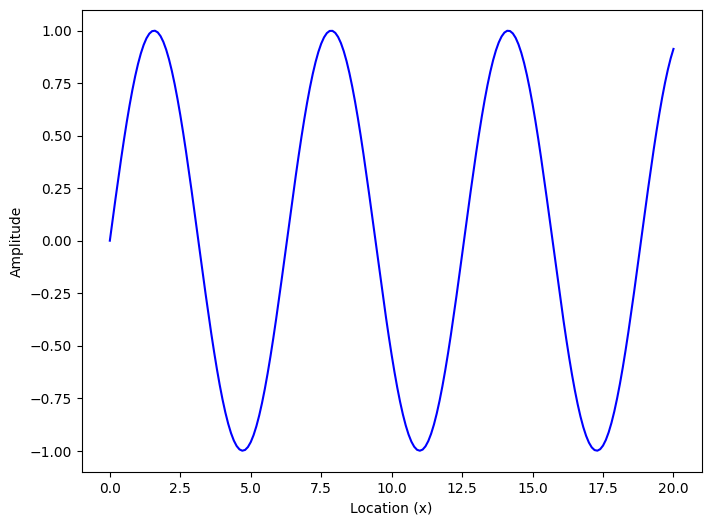

In [5]:
x = np.linspace(0, 20, 201)
y = np.sin(x)

plt.figure(figsize = (8, 6))
plt.plot(x, y, 'b')
plt.ylabel('Amplitude')
plt.xlabel('Location (x)')
plt.show()

We can think of the sine wave can change both in time and space. If we plot the changes at various locations, each time snapshot will be a sine wave changes with location. See the following figure with a fix point at $x=2.5$ showing as a red dot. Of course, you can see the changes over time at specific location as well, you can plot this by yourself.

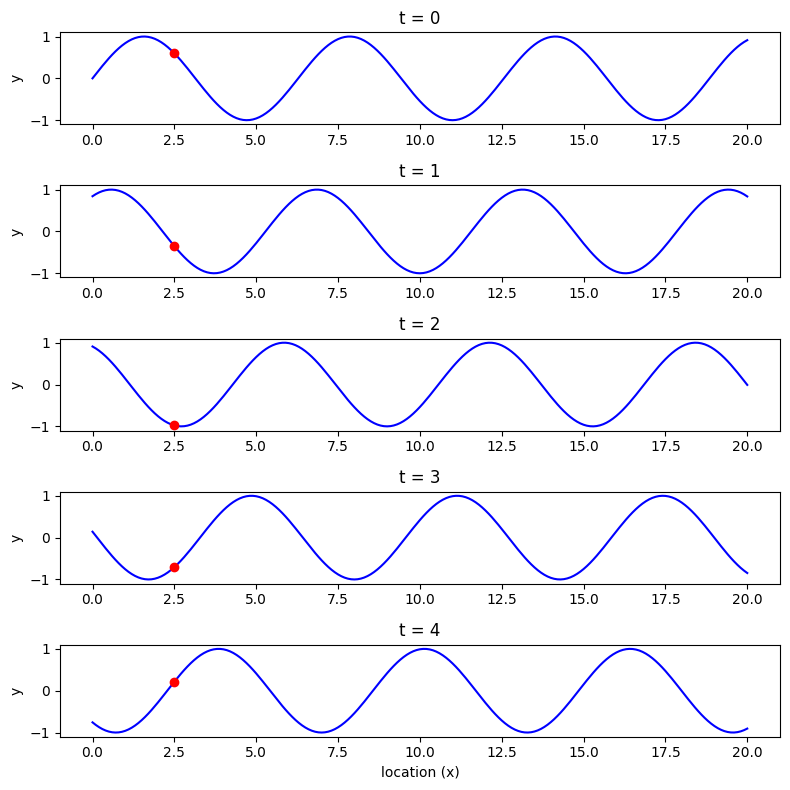

In [6]:
fig = plt.figure(figsize = (8,8))

times = np.arange(5)

n = len(times)

for t in times:
    plt.subplot(n, 1, t+1)
    y = np.sin(x + t)
    plt.plot(x, y, 'b')
    plt.plot(x[25], y [25], 'ro')
    plt.ylim(-1.1, 1.1)
    plt.ylabel('y')
    plt.title(f't = {t}')

plt.xlabel('location (x)')
plt.tight_layout()
plt.show()

## Characteristics of a wave

We can see waves can be a continuous entity both in time and space. But in reality, many times we discrete the time and space at various points. For example, we can use sensors such as accelerometers (can measure the acceleration of a movement) at different locations on the Earth to monitor the earthquakes, which is spatial discretization. Similarly, these sensors usually record the data at certain times which is a temporal discretization. For a single wave, it has different characteristics. See the following two figures.

**Amplitude** is used to describe the difference between the maximum values to the baseline value (see the above figures). A sine wave is a periodic signal, which means it repeats itself after certain time, which can be measured by **period**. Period of a wave is time it takes to finish the complete cycle, in the figure, we can see that the period can be measured from the two adjacent peaks. **Wavelength** measures the distance between two successive crests or troughs of a wave. **Frequency** describes the number of waves that pass a fixed place in a given amount of time. Frequency can be measured by how many cycles pass within 1 second. Therefore, the unit of frequency is cycles/second, or more commonly used **Hertz** (abbreviated **Hz**). Frequency is different from period, but they are related to each other. Frequency refers to how often something happens while period refers to the time it takes to complete something, mathematically,

$$period = \frac{1}{frequency}$$

From the two figures, we can also see that blue dots on the sine waves, these are the discretization points we did both in time and space. Therefore, only at these dots, we have sampled the value of the wave. Usually when we record a wave, we need to specify how often we sample the wave in time, this is called **sampling**. And this rate is called **sampling rate**, with the unit Hz. For example, if we sample a wave at 2 Hz, it means that every second we sample two data points. Since we understand more about the basics about a wave, now let's see a sine wave more carefully. A sine wave can be represented by the following equation:

$$ y(t) = Asin(\omega{t}+\phi)$$

where $A$ is the amplitude of the wave, $\omega$ is the **angular frequency**, which specifies how many cycles occur in a second, in radians per second. $\phi$ is the **phase** of the signal. If $T$ is the period of the wave, and $f$ is the frequency of the wave, then $\omega$ has the following relationship to them:

$$\omega = \frac{2\pi}{T} = 2\pi{f}$$

Here is an example of two sine waves with time between 0 and 1 seconds and frequency is 5 Hz and 10 Hz, all sampled at 100 Hz:

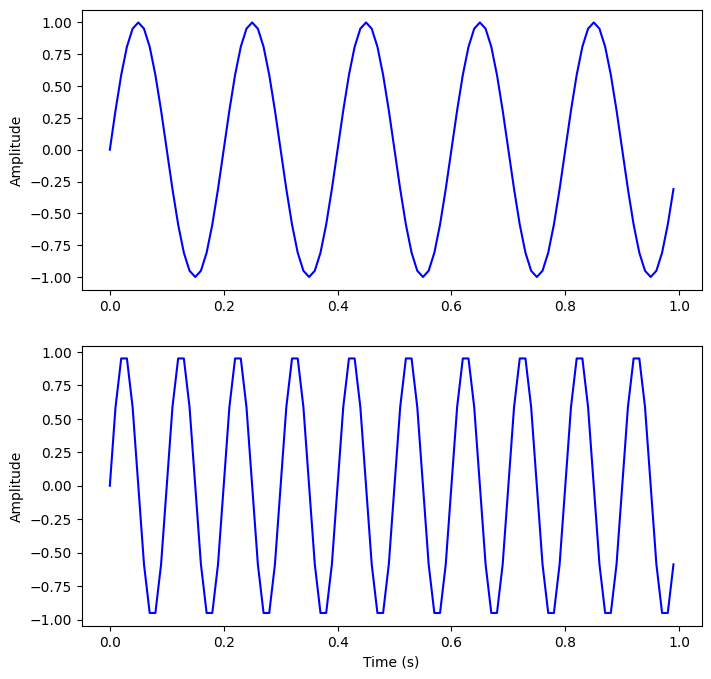

In [7]:
# sampling rate
sr = 100.0
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

# frequency of the signal
freq = 5
y = np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 8))
plt.subplot(211)
plt.plot(t, y, 'b')
plt.ylabel('Amplitude')

freq = 10
y = np.sin(2*np.pi*freq*t)

plt.subplot(212)
plt.plot(t, y, 'b')
plt.ylabel('Amplitude')

plt.xlabel('Time (s)')
plt.show()

Here is an example of two sine waves with time between 0 and 1 seconds. Both waves have frequency 5 Hz and sampled at 100 Hz, but the phase at 0 and 10, respectively:

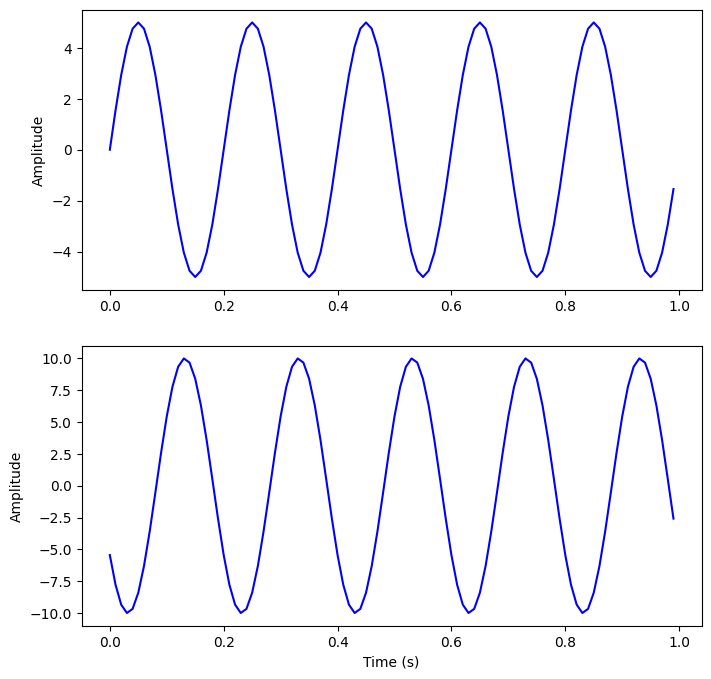

In [8]:
# frequency of the signal
freq = 5
y = 5*np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 8))
plt.subplot(211)
plt.plot(t, y, 'b')
plt.ylabel('Amplitude')

y = 10*np.sin(2*np.pi*freq*t + 10)

plt.subplot(212)
plt.plot(t, y, 'b')
plt.ylabel('Amplitude')

plt.xlabel('Time (s)')
plt.show()

# Fast Fourier Transform (FFT)

The **Fast Fourier Transform (FFT)** is an efficient algorithm to calculate the DFT of a sequence. It is described first in Cooley and Tukey's classic paper in 1965, but the idea actually can be traced back to Gauss's unpublished work in 1805. It is a divide and conquer algorithm that recursively breaks the DFT into smaller DFTs to bring down the computation. As a result, it successfully reduces the complexity of the DFT from $O(n^2)$ to $O(n\log n)$, where $n$ is the size of the data. This reduction in computation time is significant especially for data with large $N$, therefore, making FFT widely used in engineering, science and mathematics. Let's see how the FFT reduces the computation time:

## Symmetries in the DFT

The answer to how FFT speedup the computing of DFT lies in the exploitation of the symmetries in the DFT. Let's take a look of the symmetries in the DFT. From the definition of the DFT equation

$$X_k = \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{kn/N}}}$$

we can calculate the

$$X_{k+N} = \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{(k+N)n/N}}} = \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{n}}\cdot e^{-i2\pi{kn/N}}}$$

Note that, $e^{-i2\pi{n}} = 1$ (recall Euler's formula:
$e^{-i2\pi n}=\cos (-2\pi n)+i\sin (-2\pi n)=1+0i=1$), therefore, we have

$$X_{k+N} = \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{kn/N}}} = X_k$$

with a little extension, we can have

$$X_{k+i\cdot N} = X_k, \text{ for any integer i}$$

This means that within the DFT, we clearly have some symmetries that we can use to reduce the computation.

## Tricks in FFT

Since we know there are symmetries in the DFT, we can consider to use it reduce the computation, because if we need to calculate both $X_k$ and $X_{k+N}$, we only need to do this once. This is exactly the idea behind the FFT. Cooley and Tukey showed that we can calculate DFT more efficiently if we continue to divide the problem into smaller ones. Let's first divide the whole series into two parts, i.e. the even number part and the odd number part:

\begin{eqnarray*}
X_{k} &=& \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{kn/N}}} \\
      &=& \sum_{m=0}^{N/2-1}{x_{2m}\cdot e^{-i2\pi{k(2m)/N}}} + \sum_{m=0}^{N/2-1}{x_{2m+1}\cdot e^{-i2\pi{k(2m+1)/N}}} \\
      &=& \sum_{m=0}^{N/2-1}{x_{2m}\cdot e^{-i2\pi{km/(N/2)}}} + e^{-i2\pi{k/N}}\sum_{m=0}^{N/2-1}{x_{2m+1}\cdot e^{-i2\pi{km/(N/2)}}}
\end{eqnarray*}

We can see that, the two smaller terms which only have half of the size ($\frac{N}{2}$) in the above equation are two smaller DFTs. For each term, the $ 0\leq m \le \frac{N}{2}$, but $ 0\leq k \le N$, therefore, we can see that half of the values will be the same due to the symmetry properties we described above. Thus, we only need to calculate half of the fields in each term. Of course, we don't need to stop here, we can continue to divide each term into half with the even and odd values until it reaches the last two numbers, then calculation will be really simple.

This is how FFT works using this recursive approach. Let's see a quick and dirty implementation of the FFT. Note that, the input signal to FFT should have a length of power of 2. If the length is not, usually we need to fill up zeros to the next power of 2 size.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

#plt.style.use('seaborn-poster')
%matplotlib inline

In [10]:
def FFT(x):
    """
    A recursive implementation of
    the 1D Cooley-Tukey FFT, the
    input should have a length of
    power of 2.
    """
    N = len(x)

    if N == 1:
        return x
    else:
        X_even = FFT(x[::2])
        X_odd = FFT(x[1::2])
        factor = \
          np.exp(-2j*np.pi*np.arange(N)/ N)

        X = np.concatenate(\
            [X_even+factor[:int(N/2)]*X_odd,
             X_even+factor[int(N/2):]*X_odd])
        return X

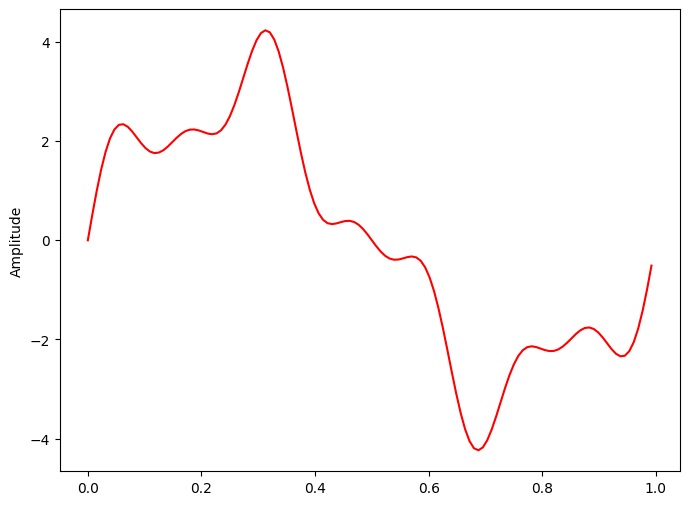

In [11]:
# sampling rate
sr = 128
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

Here is an example of using FFT to calculate the Fourier transform of the above signal. Plot the amplitude spectrum for both the two-sided and one-side frequencies:

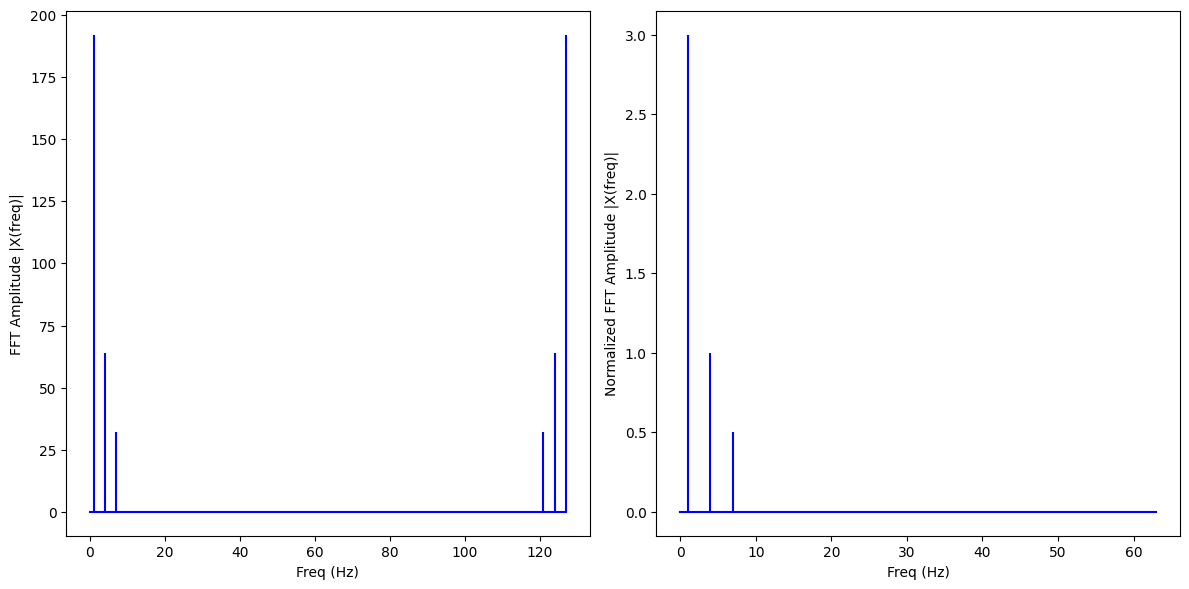

In [12]:
X=FFT(x)

# calculate the frequency
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.stem(freq, abs(X), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

# normalize the amplitude
X_oneside =X[:n_oneside]/n_oneside

plt.subplot(122)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('Normalized FFT Amplitude |X(freq)|')
plt.tight_layout()
plt.show()

Here is an example of a simple signal for length 2048, calculating the time it will take to run the FFT. As an exercise, compare the speed of the implementation above with just using the DFT.

In [13]:
def gen_sig(sr):
    '''
    function to generate
    a simple 1D signal with
    different sampling rate
    '''
    ts = 1.0/sr
    t = np.arange(0,1,ts)

    freq = 1.
    x = 3*np.sin(2*np.pi*freq*t)
    return x

In [14]:
# sampling rate =2048
sr = 2048
%timeit FFT(gen_sig(sr))

6.54 ms ± 56.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
def DFT(x):
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j * np.pi * k * n / N)
    return np.dot(e, x)

In [16]:
# sampling rate =2048
sr = 2048
%timeit DFT(gen_sig(sr))

51.5 ms ± 53.4 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


We can see that, for a signal with length 2048 (about 2000), FFT implementation is faster than using DFT. Note that, there are also a lot of ways to optimize the FFT implementation which will make it faster. Next, we will take a look of the Python built-in FFT functions, which will be much faster.

# FFT in Python

In Python, there are very mature FFT functions both in *numpy* and _scipy_. In this section, we will take a look of both packages and see how we can easily use them in our work. Let's first generate the signal as before.

In [17]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

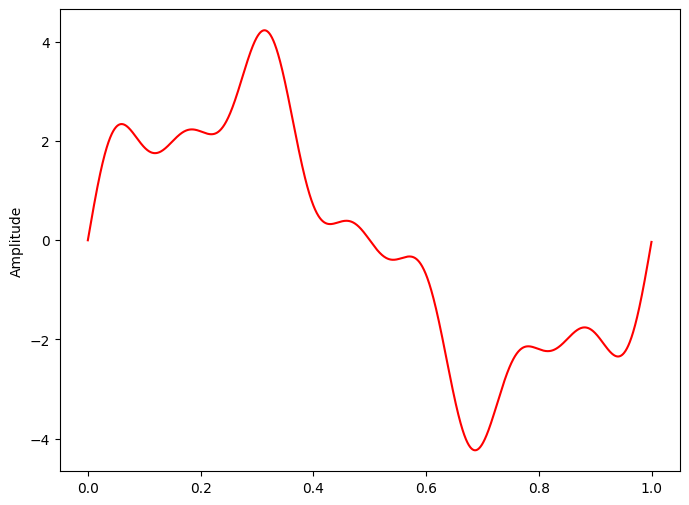

In [18]:
# sampling rate
sr = 2000
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

## FFT in Numpy

**EXAMPLE:** Use *fft* and _ifft_ function from *numpy* to calculate the FFT amplitude spectrum and inverse FFT to obtain the original signal. Plot both results. Time the _fft_ function using this 2000 length signal.

/opt/homebrew/anaconda3/envs/torch/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/anaconda3/envs/torch/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


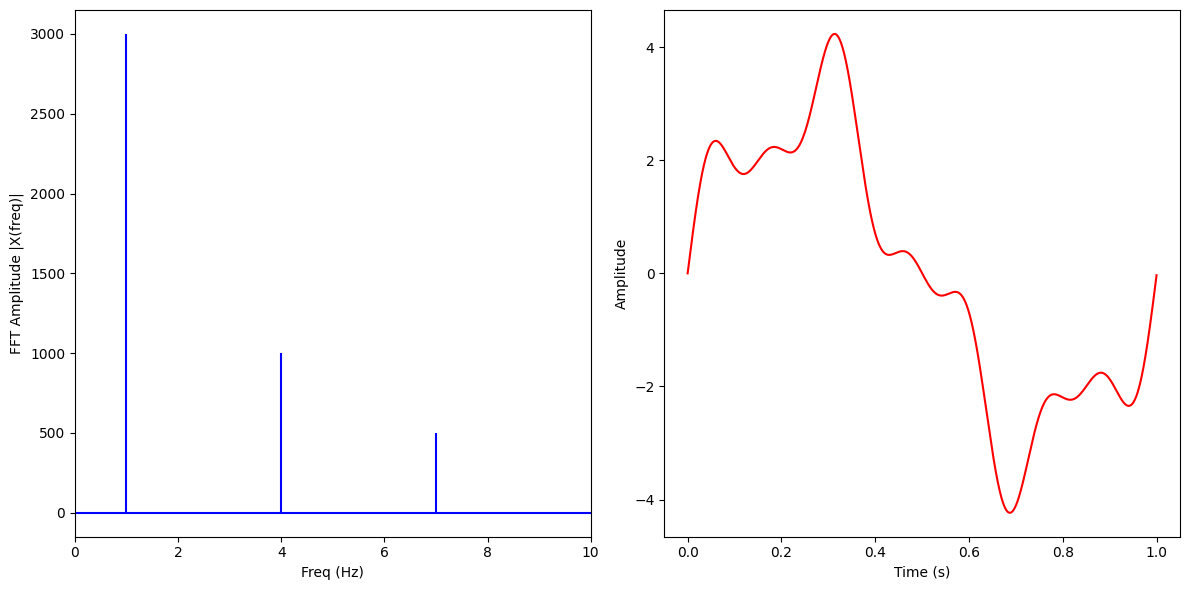

In [19]:
from numpy.fft import fft, ifft

X = fft(x)
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (12, 6))
plt.subplot(121)

plt.stem(freq, np.abs(X), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0, 10)

plt.subplot(122)
plt.plot(t, ifft(X), 'r')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [20]:
%timeit fft(x)

11.9 μs ± 48.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## FFT in Scipy

**EXAMPLE:** Use *fft* and _ifft_ function from *scipy* to calculate the FFT amplitude spectrum and inverse FFT to obtain the original signal. Plot both results. Time the _fft_ function using this 2000 length signal.

/opt/homebrew/anaconda3/envs/torch/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/anaconda3/envs/torch/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


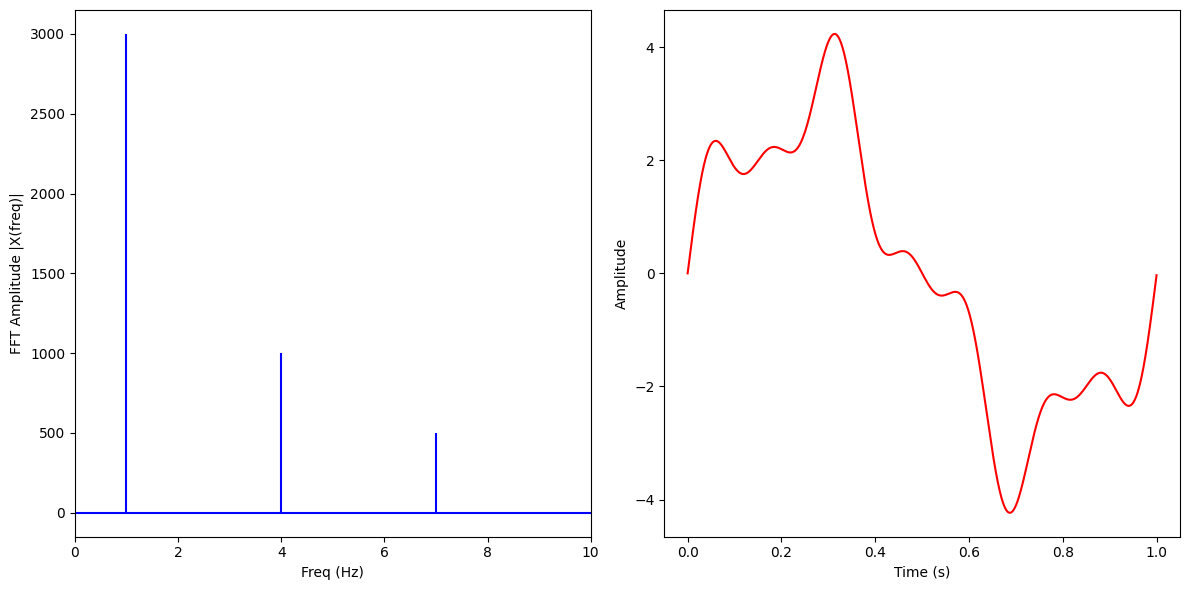

In [21]:
from scipy.fftpack import fft, ifft

X = fft(x)

plt.figure(figsize = (12, 6))
plt.subplot(121)

plt.stem(freq, np.abs(X), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0, 10)

plt.subplot(122)
plt.plot(t, ifft(X), 'r')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [22]:
%timeit fft(x)

12.3 μs ± 51.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Filtering a signal using FFT

Filtering is a process in signal processing to remove some unwanted part of the signal within certain frequency range. There are low-pass filter, which tries to remove all the signal above certain cut-off frequency, and high-pass filter, which does the opposite. Combining low-pass and high-pass filter, we will have bandpass filter, which means we only keep the signals within a pair of frequencies. Using FFT, we can easily do this. Let us play with the following example to illustrate the basics of a band-pass filter. Note: we just want to show the idea of filtering using very basic operations, in reality, the filtering process are much more sophisticated.  

**EXAMPLE:** We can use the signal we generated at the beginning of this section (the mixed sine waves with 1, 4, and 7 Hz), and high-pass filter this signal at 6 Hz. Plot the filtered signal and the FFT amplitude before and after the filtering.

In [23]:
from scipy.fftpack import fftfreq

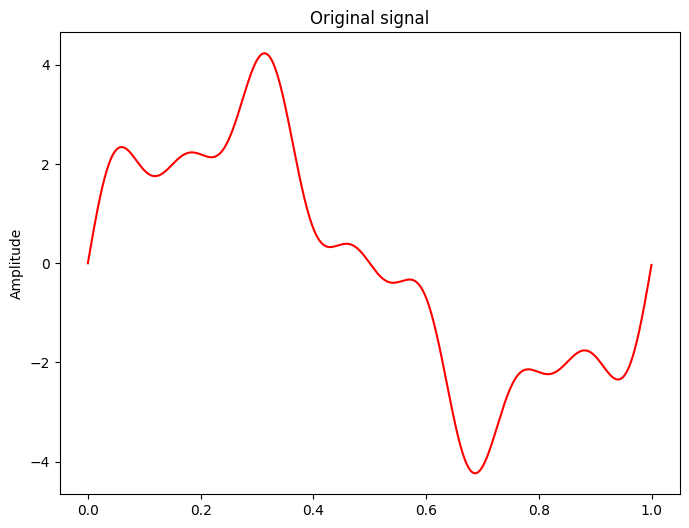

In [24]:
plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')
plt.title('Original signal')
plt.show()

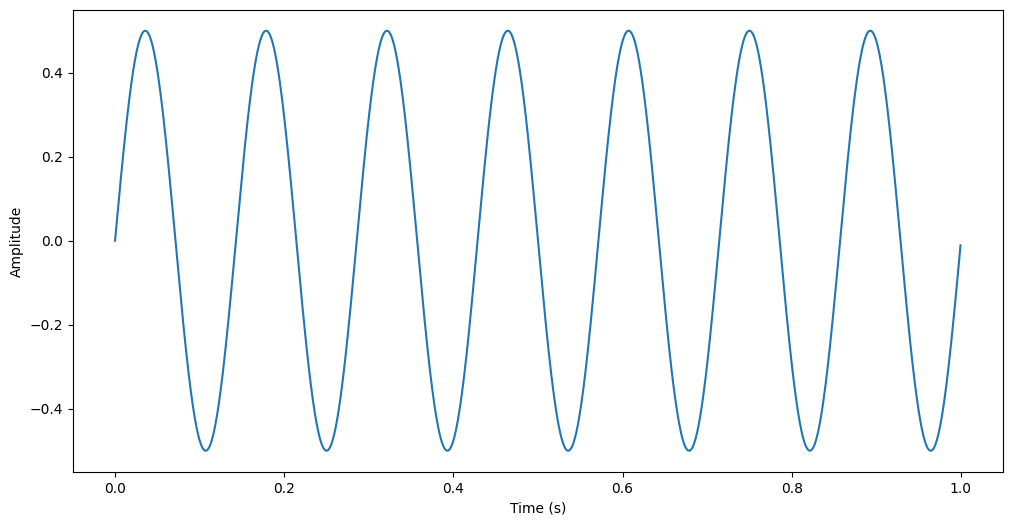

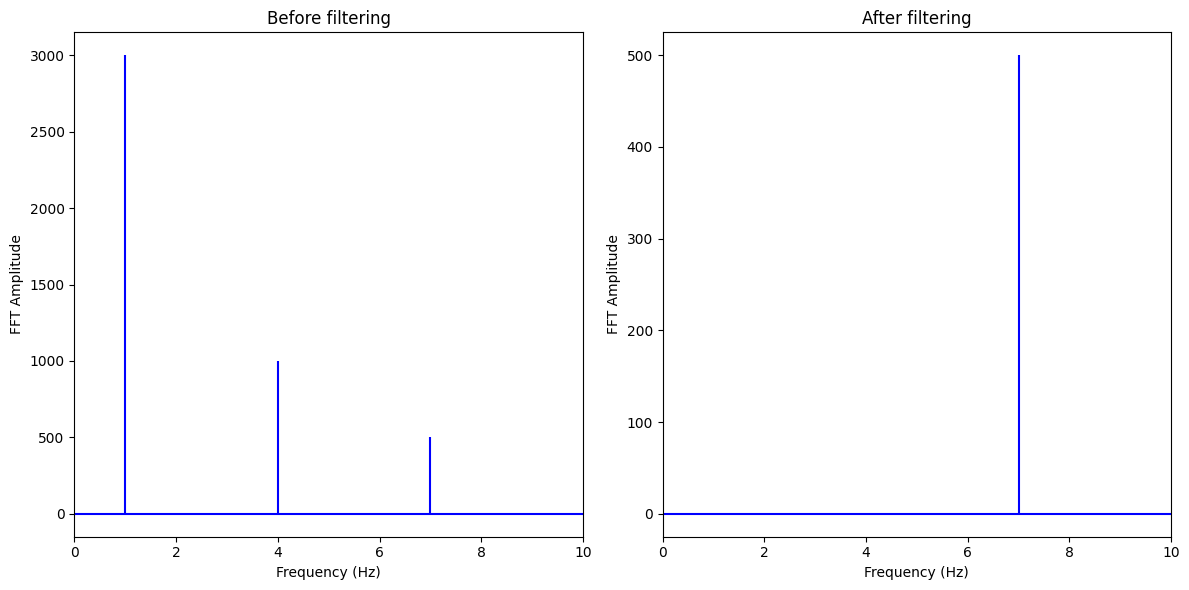

In [25]:
# FFT the signal
sig_fft = fft(x)
# copy the FFT results
sig_fft_filtered = sig_fft.copy()

# obtain the frequencies using scipy function
freq = fftfreq(len(x), d=1./2000)

# define the cut-off frequency
cut_off = 6

# high-pass filter by assign zeros to the
# FFT amplitudes where the absolute
# frequencies smaller than the cut-off
sig_fft_filtered[np.abs(freq) < cut_off] = 0

# get the filtered signal in time domain
filtered = ifft(sig_fft_filtered)

# plot the filtered signal
plt.figure(figsize = (12, 6))
plt.plot(t, filtered)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# plot the FFT amplitude before and after
plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.stem(freq, np.abs(sig_fft), 'b', \
         markerfmt=" ", basefmt="-b")
plt.title('Before filtering')
plt.xlim(0, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('FFT Amplitude')
plt.subplot(122)
plt.stem(freq, np.abs(sig_fft_filtered), 'b', \
         markerfmt=" ", basefmt="-b")
plt.title('After filtering')
plt.xlim(0, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('FFT Amplitude')
plt.tight_layout()
plt.show()

From the above example, by assigning any absolute frequencies' FFT amplitude to zero, and returning back to time domain signal, we achieve a very basic high-pass filter in a few steps. You can try to implement a simple low-pass or bandpass filter by yourself. Therefore, FFT can help us get the signal we are interested in and remove the ones that are unwanted.


## Homework 9-1:

Compare the execution time of each fft implementation and built-in function:

* Implemented DFT:
* Implemented FFT:
* Numpy FFT:
* Scipy FFT:

In [26]:
from timeit import timeit
from numpy.fft import fft as np_fft
from scipy.fftpack import fft as sp_fft

sr = 2048
signal = gen_sig(sr)

# Helper to average repeated runs for a fairer comparison.
def avg_time(fn, number=3):
    return timeit(fn, number=number) / number

# Time each implementation on the same 2048-sample signal.
timings = {
    "Implemented DFT": avg_time(lambda: DFT(signal.copy()), number=1),
    "Implemented FFT": avg_time(lambda: FFT(signal.copy())),
    "NumPy FFT": avg_time(lambda: np_fft(signal.copy())),
    "SciPy FFT": avg_time(lambda: sp_fft(signal.copy()))
}

for label, seconds in timings.items():
    print(f"{label:>20s}: {seconds*1000:.2f} ms")


     Implemented DFT: 52.80 ms
     Implemented FFT: 6.73 ms
           NumPy FFT: 0.02 ms
           SciPy FFT: 0.02 ms


## Homework 9-2

Here we consider an example of using FFT in a real-world application; electricity demand. You can find the data from [U.S. Energy Information Administration](https://www.eia.gov/beta/electricity/gridmonitor/dashboard/electric_overview/US48/US48).

1- Download the usage for a particular grid, for example the New York Independent System Operator or California Independent System Operator, for the past 31 day.

1- Use `pandas` to read the CSV file, and then store the data.

2- Plot the data and see how the electricity demand is changing over time.

3- From the plotted time series, it is hard to see if there are some patterns in the data. Transform the data into frequency domain and describe your observation.

4- Plot the results using hours and highlight some of the hours associated with the peaks. Do you see any patterns indicating peak hours?

In [27]:
import pandas as pd
from pathlib import Path
from numpy.fft import rfft, rfftfreq

# File provided via the EIA dashboard export (already included in the repo).
data_path = Path('data/electricity_demand.csv')
timestamp_col = 'Timestamp (Hour Ending)'
load_col = 'Demand (MWh)'

if not data_path.exists():
    raise FileNotFoundError(
        f"{data_path} not found. Download a 31-day CSV and keep it at the same path.")

# Read, clean, and sort the measurements.
raw_df = pd.read_csv(
    data_path,
    parse_dates=[timestamp_col],
    infer_datetime_format=True
)
df = (raw_df[[timestamp_col, load_col]]
        .dropna()
        .copy())
df.columns = ['timestamp', 'demand_mwh']
df['demand_mw'] = pd.to_numeric(df['demand_mwh'], errors='coerce')
df = df.loc[pd.notna(df['demand_mw'])].copy()
df = df.sort_values(by='timestamp').reset_index(drop=True)

df['hours_since_start'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds() / 3600

plt.figure(figsize=(12, 4))
plt.plot(df['timestamp'], df['demand_mw'])
plt.title('Electricity Demand Over Time (US48)')
plt.ylabel('Demand (MWh)')
plt.xlabel('Timestamp (hour ending)')
plt.tight_layout()
plt.show()

if len(df) < 2:
    print('Not enough samples for FFT-based frequency analysis. Add more hourly rows to the CSV to reveal peak periods.')
else:
    # Prepare evenly sampled demand series and remove the DC component before the FFT.
    demand = df['demand_mw'].to_numpy()
    detrended = demand - demand.mean()

    # Estimate the sampling interval in hours directly from the timestamps.
    dt_hours = df['timestamp'].diff().dt.total_seconds().median() / 3600
    freqs = rfftfreq(len(detrended), d=dt_hours)
    amplitudes = np.abs(rfft(detrended)) / len(detrended)

    # Convert frequency (cycles/hour) to period (hours/cycle) for interpretation.
    valid = freqs > 0
    period_hours = 1 / freqs[valid]
    amp_valid = amplitudes[valid]

    # Identify the dominant peaks (ignoring the zero-frequency component).
    peak_count = min(3, amp_valid.size)
    peak_indices = np.argsort(amp_valid)[-peak_count:]
    peak_periods = period_hours[peak_indices]
    peak_amps = amp_valid[peak_indices]

    plt.figure(figsize=(12, 4))
    plt.plot(period_hours, amp_valid)
    for p, a in zip(peak_periods, peak_amps):
        plt.axvline(p, color='r', linestyle='--', alpha=0.4)
        plt.annotate(f"~{p:.1f} h", xy=(p, a), xytext=(p+2, a*1.1),
                     arrowprops=dict(arrowstyle='->', color='red'), color='red')
    plt.xlim(0, min(period_hours.max(), 60))
    plt.xlabel('Period (hours per cycle)')
    plt.ylabel('FFT amplitude (MW)')
    plt.title('Dominant Periodicities in Demand (frequency domain)')
    plt.tight_layout()
    plt.show()

    print('Peak periods (hours) and their relative amplitudes:')
    for p, a in sorted(zip(peak_periods, peak_amps)):
        print(f"  Period ≈ {p:.2f} hours | amplitude ≈ {a:.2f} MW")


/var/folders/hl/18z9x6cd0cs071nkgz798m6h0000gn/T/ipykernel_238/1873570292.py:15: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  raw_df = pd.read_csv(
/var/folders/hl/18z9x6cd0cs071nkgz798m6h0000gn/T/ipykernel_238/1873570292.py:15: FutureWarning: Parsing 'EST' as tzlocal (dependent on system timezone) is deprecated and will raise in a future version. Pass the 'tz' keyword or call tz_localize after construction instead
  raw_df = pd.read_csv(


AttributeError: 'NoneType' object has no attribute 'total_seconds'

# Homework 9-3

1. For a signal t = [0, 1, 2, 3], and y = [0, 3, 2, 0], find the real DFT. Find the inverse DFT. Don't use Python to find the results, instead write out the equations and calculate the values.
2. Generate two signals, signal 1 is a sine wave with 5 Hz, amplitude 3 and phase shift 3, signal 2 is a sine wave with 2 Hz, amplitude 2 and phase shift -2. Plot the signal for 2 seconds.
3. Sample the signal you generated using a sampling rate 5, 10, 20, 50, and 100 Hz, and see the differences between different sampling rates.
4. What are the amplitude and phase of the DFT values for a signal?
5. Use the DFT function above and implement the inverse Discrete Fourier Transform in Python similarly?
6. Use the DFT function and inverse DFT and generate the amplitude spectrum for the signal you generated. Normalize the DFT amplitude to get the correct corresponding time domain amplitude.
7. Describe the tricks used in FFT to make the computation faster?
8. Use the fft and ifft function from scipy to repeat the problem above.
9. Adding a random normal distribution noise into the signal in your signal  using numpy and plot the FFT amplitude spectrum, what do you see?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft as sp_fft, ifft as sp_ifft

# 1. Manual DFT/IDFT reasoning for t=[0,1,2,3], y=[0,3,2,0]
manual_summary = """
X0 = 0 + 3 + 2 + 0 = 5
X1 = 3e^{-i\pi/2} + 2e^{-i\pi} = -2 - 3i
X2 = 3e^{-i\pi} + 2e^{-i2\pi} = -1
X3 = 3e^{-i3\pi/2} + 2e^{-i3\pi} = -2 + 3i

Inverse DFT:
y_n = (1/4) * sum_k X_k e^{i2\pi kn/4} → [0, 3, 2, 0]
"""
print(manual_summary)

# 2. Generate and plot the two sine waves and their sum for 2 seconds.
duration = 2.0
high_sr = 1000
high_t = np.linspace(0, duration, int(high_sr * duration), endpoint=False)
signal1 = 3 * np.sin(2 * np.pi * 5 * high_t + 3)
signal2 = 2 * np.sin(2 * np.pi * 2 * high_t - 2)
composite = signal1 + signal2

plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(high_t, signal1)
plt.title('Signal 1: 5 Hz, amplitude 3, phase 3')
plt.subplot(3, 1, 2)
plt.plot(high_t, signal2)
plt.title('Signal 2: 2 Hz, amplitude 2, phase -2')
plt.subplot(3, 1, 3)
plt.plot(high_t, composite)
plt.title('Composite Signal (Signal 1 + Signal 2)')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# 3. Sample the composite signal at different rates to illustrate aliasing/resolution.
sample_rates = [5, 10, 20, 50, 100]
fig, axes = plt.subplots(len(sample_rates), 1, figsize=(10, 10), sharex=True)
for ax, sr in zip(axes, sample_rates):
    t_samples = np.arange(0, duration, 1 / sr)
    sampled = 3 * np.sin(2 * np.pi * 5 * t_samples + 3) + \
              2 * np.sin(2 * np.pi * 2 * t_samples - 2)
    ax.plot(high_t, composite, color='lightgray', linewidth=1, label='Reference (1000 Hz)')
    ax.stem(t_samples, sampled, linefmt='C1-', markerfmt='C1o', basefmt=' ')
    ax.set_ylabel(f'{sr} Hz')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Sampling the Composite Signal at Different Rates')
plt.tight_layout()
plt.show()

# 4. Amplitude & phase meaning for DFT coefficients.
print('DFT coefficient interpretation: amplitude = |X_k| / (N/2) (for one-sided spectra), phase = atan2(Im, Re).\n')

# 5. Inverse DFT implementation.
def IDFT(X):
    N = len(X)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(2j * np.pi * k * n / N)
    return (1 / N) * np.dot(e, X)

# 6. Use DFT/IDFT to obtain amplitude spectrum and reconstruction.
X = DFT(composite)
reconstructed = IDFT(X).real
freqs = np.fft.fftfreq(len(composite), d=1 / high_sr)
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]
amp_norm = (2 / len(X)) * np.abs(X[pos_mask])
amp_norm[0] /= 2  # DC component should not be doubled.

plt.figure(figsize=(12, 4))
plt.plot(high_t, composite, label='Original')
plt.plot(high_t, reconstructed, '--', label='IDFT Reconstruction')
plt.legend()
plt.title('Composite Signal vs. IDFT Reconstruction')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.stem(freqs_pos, amp_norm, basefmt=' ')
plt.xlim(0, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized amplitude')
plt.title('Normalized Amplitude Spectrum via DFT')
plt.tight_layout()
plt.show()

# 7. FFT speedup explanation.
fft_summary = """
FFT tricks:
1. Split the sequence into even/odd indices recursively (divide & conquer).
2. Reuse twiddle factors exploiting periodicity e^{-i2πk/N}.
3. Stop at length-2 transforms to minimize arithmetic.
4. Recombine partial transforms using symmetry so results are shared.
"""
print(fft_summary)

# 8. Repeat using SciPy fft/ifft for validation.
X_scipy = np.asarray(sp_fft(composite))
ifft_scipy = np.real(np.asarray(sp_ifft(X_scipy)))
print(f'SciPy fft match with custom DFT? {np.allclose(X_scipy, X, atol=1e-9)}')
print(f'SciPy ifft match with custom IDFT? {np.allclose(ifft_scipy, reconstructed, atol=1e-9)}')

# 9. Add random noise and inspect FFT amplitude spectrum.
np.random.seed(0)
noisy = composite + np.random.normal(scale=0.5, size=composite.shape)
noisy_fft = np.fft.rfft(noisy)
noisy_freqs = np.fft.rfftfreq(len(noisy), d=1 / high_sr)
noisy_amp = (2 / len(noisy)) * np.abs(noisy_fft)
noisy_amp[0] /= 2

plt.figure(figsize=(12, 4))
plt.plot(high_t, noisy, label='Noisy signal')
plt.plot(high_t, composite, alpha=0.6, label='Clean reference')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Composite Signal with Added Gaussian Noise')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.stem(noisy_freqs, noisy_amp, basefmt=' ')
plt.xlim(0, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized amplitude')
plt.title('FFT Amplitude Spectrum with Noise (noise raises the noise floor)')
plt.tight_layout()
plt.show()


# Summary


1. We learned the basics of the waves, frequency, period, amplitude and wavelength are the characteristics of the waves.
2. The Discrete Fourier Transform (DFT) is a way to transform a signal from time domain to frequency domain using the sum of a sequence of sine waves.
3. The Fast Fourier Transform (FFT) is an algorithm to calculate the DFTs efficiently by taking advantage of the symmetry properties in DFT.